# Predicción de riesgo en inspecciones sanitarias con CatBoost

## Objetivo

Estimar la probabilidad de que una inspección sanitaria programada en Chicago obtenga un resultado `Fail`, utilizando exclusivamente información disponible antes de realizarla.

## Pregunta de modelado

> Entre las inspecciones programadas, ¿cuáles presentan mayor probabilidad de obtener un resultado `Fail`, utilizando exclusivamente información conocida antes de su realización?

## Unidad de observación

Una inspección realizada a un establecimiento.

## Variable objetivo

- `1`: resultado `Fail`.
- `0`: resultado `Pass` o `Pass w/ Conditions`.

Se excluyen resultados que no representan una evaluación sanitaria completada, como `Out of Business`, `No Entry` y `Not Ready`.

## Restricción importante

La variable `violations` no se utiliza como predictor porque contiene información obtenida durante la propia inspección. Se asume que el tipo de inspección y el resto de las variables selecciónadas son conocidos antes de iniciar la visita.


## 1. Carga de datos

El archivo original se mantiene localmente en `data/raw/` y no se versiona en GitHub. El notebook debe ejecutarse desde la carpeta del experimento.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
RAW_FILE = PROJECT_DIR / "data" / "raw" / "food_inspections.csv"
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

if not RAW_FILE.exists():
    raise FileNotFoundError(
        "No se encontro data/raw/food_inspections.csv. "
        "Ejecuta el notebook desde la carpeta del experimento."
    )

df_raw = pd.read_csv(
    RAW_FILE,
    low_memory=False,
)

print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")


Filas: 315,801
Columnas: 17


In [2]:
df_raw.head()


,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location
0,2642944,Southside Occupational Academy.,Southside Occupational Academy.,49031.0,School,Risk 1 (High),7342 S Hoyne (2100W),CHICAGO,IL,60636.0,09/18/2026,Canvass,Pass w/ Conditions,40. PERSONAL CLEANLINESS - Comments: Food hand...,41.759868,-87.675984,"(41.75986812942321, -87.67598380492386)"
1,2642950,BABA SHAWARMA INC.,HALAL SMASH BURGER & PHILLIES,2934768.0,Restaurant,Risk 1 (High),6404 N CALIFORNIA AVE,CHICAGO,IL,60645.0,09/18/2026,Complaint Re-Inspection,Fail,37. FOOD PROPERLY LABELED; ORIGINAL CONTAINER ...,41.997764,-87.699796,"(41.9977637602161, -87.69979572191909)"
2,2642945,EDIBLE ARRANGEMENTS,EDIBLE ARRANGEMENTS,2900712.0,Restaurant,Risk 1 (High),1465 E HYDE PARK BLVD,CHICAGO,IL,60615.0,09/18/2026,Canvass,Out of Business,NaN,41.802344,-87.589218,"(41.802344169636754, -87.58921808934608)"
3,2642925,MENTA ACADEMY MIDWAY SOUTHWEST,MENTA ACADEMY MIDWAY SOUTHWEST,4075688.0,School,Risk 1 (High),6340 S NEW ENGLAND AVE,CHICAGO,IL,60638.0,09/18/2026,Canvass,Fail,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,41.776291,-87.793599,"(41.77629122851704, -87.79359903646485)"
4,2642942,87TH QUICK STOP,87TH QUICK STOP,3100285.0,Grocery Store,Risk 2 (Medium),1833-1835 W 87TH ST,CHICAGO,IL,60620.0,09/18/2026,License,Pass,"38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - ...",41.735598,-87.669267,"(41.73559791871549, -87.66926691423934)"


## 2. Auditoría inicial de los datos

Antes de filtrar o construir variables, revisamos la estructura, el período disponible, los resultados posibles y la presencia de identificadores duplicados.


In [3]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

df["inspection_date"] = pd.to_datetime(
    df["inspection_date"],
    format="%m/%d/%Y",
    errors="coerce",
)

df.columns.tolist()


['inspection_id',
 'dba_name',
 'aka_name',
 'license',
 'facility_type',
 'risk',
 'address',
 'city',
 'state',
 'zip',
 'inspection_date',
 'inspection_type',
 'results',
 'violations',
 'latitude',
 'longitude',
 'location']

In [4]:
print("Periodo disponible:")
print(df["inspection_date"].agg(["min", "max"]))

print("\nResultados de inspección:")
print(df["results"].value_counts(dropna=False))

print("\nInspection ID duplicados:")
print(df["inspection_id"].duplicated().sum())


Periodo disponible:
min   2010-01-04
max   2026-09-18
Name: inspection_date, dtype: datetime64[us]

Resultados de inspección:
results
Pass                    163447
Fail                     60814
Pass w/ Conditions       46853
Out of Business          25866
No Entry                 14129
Not Ready                 4596
Business Not Located        96
Name: count, dtype: int64

Inspection ID duplicados:
0


## 3. Definición de la población y variable objetivo

El análisis se restringe al período 2019–2025. Solo se consideran inspecciones sanitarias completadas:

- `Fail` se codifica como `1`.
- `Pass` y `Pass w/ Conditions` se codifican como `0`.

Los demás resultados se excluyen. El conjunto de prueba de 2025 permanece reservado: antes de la evaluación final no se muestran sus fallas ni su tasa objetivo.


In [5]:
START_DATE = "2019-01-01"
END_DATE = "2025-12-31"

VALID_RESULTS = [
    "Pass",
    "Pass w/ Conditions",
    "Fail",
]

date_mask = df["inspection_date"].between(
    START_DATE,
    END_DATE,
    inclusive="both",
)

df_period = df.loc[date_mask].copy()

df_model = df_period.loc[
    df_period["results"].isin(VALID_RESULTS)
].copy()

df_model["failed_inspection"] = (
    df_model["results"]
    .eq("Fail")
    .astype("int8")
)

# Informacion obtenida durante la inspección: no puede ser predictora.
df_model = df_model.drop(columns=["violations"])

development_mask = df_model["inspection_date"].dt.year.le(2024)

print(f"Inspecciónes entre 2019 y 2025: {len(df_period):,}")
print(f"Inspecciónes evaluables: {len(df_model):,}")
print(f"Registros excluidos: {len(df_period) - len(df_model):,}")
print(
    "Tasa de Fail disponible para desarrollo (2019–2024): "
    f"{df_model.loc[development_mask, 'failed_inspection'].mean():.2%}"
)
print("Resultados objetivo de 2025: reservados")


Inspecciónes entre 2019 y 2025: 123,673
Inspecciónes evaluables: 103,614
Registros excluidos: 20,059
Tasa de Fail disponible para desarrollo (2019–2024): 23.36%
Resultados objetivo de 2025: reservados


In [6]:
# El resumen descriptivo excluye 2025 para proteger el test final.
yearly_summary = (
    df_model.loc[development_mask]
    .assign(year=lambda data: data["inspection_date"].dt.year)
    .groupby("year")
    .agg(
        inspections=("inspection_id", "size"),
        failures=("failed_inspection", "sum"),
        failure_rate=("failed_inspection", "mean"),
    )
)

yearly_summary["failure_rate"] = (
    yearly_summary["failure_rate"] * 100
).round(2)

yearly_summary


,inspections,failures,failure_rate
year,,,
2019,16121,3612,22.41
2020,12600,2935,23.29
2021,13139,3035,23.10
2022,14286,3554,24.88
2023,15413,3835,24.88
2024,15995,3481,21.76


## 4. Separación temporal

La evaluación simula el uso del modelo a través del tiempo:

- **Entrenamiento:** 2019–2023.
- **Validación:** 2024, utilizada para comparar modelos y aplicar *early stopping*.
- **Prueba final:** 2025, reservada hasta congelar por completo el procedimiento.


In [7]:
train_df = df_model.loc[
    df_model["inspection_date"].dt.year.between(2019, 2023)
].copy()

validation_df = df_model.loc[
    df_model["inspection_date"].dt.year.eq(2024)
].copy()

test_df = df_model.loc[
    df_model["inspection_date"].dt.year.eq(2025)
].copy()

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "period": ["2019–2023", "2024", "2025"],
    "inspections": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "failures": [
        f"{int(train_df['failed_inspection'].sum()):,}",
        f"{int(validation_df['failed_inspection'].sum()):,}",
        "Reservado",
    ],
    "failure_rate": [
        f"{train_df['failed_inspection'].mean():.2%}",
        f"{validation_df['failed_inspection'].mean():.2%}",
        "Reservado",
    ],
    "status": [
        "Entrenamiento",
        "Selección de modelos",
        "Prueba reservada",
    ],
})

split_summary


,split,period,inspections,failures,failure_rate,status
0,train,2019–2023,71559,"16,971",23.72%,Entrenamiento
1,validation,2024,15995,"3,481",21.76%,Selección de modelos
2,test,2025,16060,Reservado,Reservado,Prueba reservada


## 5. Selección inicial de variables

Se utilizan variables conocidas antes de comenzar la inspección.

### Variables categóricas

- Tipo de establecimiento.
- Clasificacion de riesgo.
- Tipo de inspección.
- Código postal.
- Mes de la inspección.
- Día de la semana.

### Variables numéricas

- Latitud.
- Longitud.

No se utilizan inicialmente el nombre, la direccion ni el número de licencia como predictores directos, porque podrían favorecer la memorizacion de establecimientos especificos. La licencia puede utilizarse posteriormente para construir variables históricas sin fuga temporal.


In [8]:
def add_temporal_features(data):
    result = data.copy()
    result["inspection_month"] = result["inspection_date"].dt.month
    result["inspection_weekday"] = result["inspection_date"].dt.day_name()
    return result


train_df = add_temporal_features(train_df)
validation_df = add_temporal_features(validation_df)
test_df = add_temporal_features(test_df)

categorical_features = [
    "facility_type",
    "risk",
    "inspection_type",
    "zip",
    "inspection_month",
    "inspection_weekday",
]

numeric_features = [
    "latitude",
    "longitude",
]

feature_columns = categorical_features + numeric_features


In [9]:
feature_audit = pd.DataFrame({
    "data_type": train_df[feature_columns].dtypes.astype(str),
    "missing_values": train_df[feature_columns].isna().sum(),
    "missing_pct": (
        train_df[feature_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    "unique_values": train_df[feature_columns].nunique(dropna=True),
})

feature_audit.sort_values("missing_pct", ascending=False)


,data_type,missing_values,missing_pct,unique_values
latitude,float64,259,0.36,12691
longitude,float64,259,0.36,12691
facility_type,str,75,0.10,235
risk,str,2,0.00,3
zip,float64,3,0.00,92
inspection_type,str,0,0.00,16
inspection_weekday,str,0,0.00,7
inspection_month,int32,0,0.00,12


## 6. Protocolo de evaluación y tasa general

La referencia mínima asigna a todas las inspecciones la tasa de fallas observada durante el entrenamiento.

Los modelos se comparan mediante:

- **Average Precisión (AP):** métrica principal de ordenamiento para la clase positiva.
- **ROC AUC:** capacidad general de discriminación.
- **Precisión@10%:** proporción de fallas dentro del 10 % con mayor riesgo.
- **Lift@10%:** mejora de Precisión@10% respecto de la tasa real de validación.
- **Brier Score:** error cuadrático de las probabilidades; valores menores son mejores.
- **Tiempo observado:** preparación y ajuste en una ejecución local; no constituye un benchmark exhaustivo.


In [10]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)

X_train_raw = train_df[feature_columns].copy()
y_train = train_df["failed_inspection"].copy()

X_validation_raw = validation_df[feature_columns].copy()
y_validation = validation_df["failed_inspection"].copy()


def evaluate_predictions(
    model_name,
    y_true,
    probabilities,
    training_seconds=np.nan,
    top_fraction=0.10,
):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    base_rate = y_true.mean()

    # Una predicción constante no genera un ranking real.
    if np.unique(probabilities).size == 1:
        precision_at_top = base_rate
    else:
        top_n = max(1, int(np.ceil(len(y_true) * top_fraction)))
        top_indices = np.argsort(probabilities)[::-1][:top_n]
        precision_at_top = y_true[top_indices].mean()

    lift_at_top = precision_at_top / base_rate

    return {
        "model": model_name,
        "average_precision": average_precision_score(
            y_true,
            probabilities,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
        ),
        "precision_at_10_pct": precision_at_top,
        "lift_at_10_pct": lift_at_top,
        "brier_score": brier_score_loss(
            y_true,
            probabilities,
        ),
        "training_seconds": training_seconds,
    }


In [11]:
general_failure_rate = y_train.mean()

baseline_validation_probability = np.full(
    len(y_validation),
    general_failure_rate,
)

baseline_validation_result = evaluate_predictions(
    model_name="Tasa general",
    y_true=y_validation,
    probabilities=baseline_validation_probability,
    training_seconds=0.0,
)

pd.DataFrame([baseline_validation_result]).round(4)


,model,average_precision,roc_auc,precision_at_10_pct,lift_at_10_pct,brier_score,training_seconds
0,Tasa general,0.2176,0.5,0.2176,1.0,0.1706,0.0


## 7. Regresión logística con one-hot encoding

La regresión logística funciona como baseline tradicional. Las variables categóricas se imputan y codifican mediante one-hot encoding; las numéricas se imputan y estandarizan. Todo el preprocesamiento se ajusta exclusivamente con entrenamiento.


In [12]:
from time import perf_counter

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
            ),
        ),
    ]
)

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

traditional_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_preprocessor,
            categorical_features,
        ),
        (
            "numeric",
            numeric_preprocessor,
            numeric_features,
        ),
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", traditional_preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                l1_ratio=0.0,
                C=1.0,
                max_iter=2_000,
                random_state=42,
            ),
        ),
    ]
)


In [13]:
logistic_start_time = perf_counter()

logistic_model.fit(
    X_train_raw,
    y_train,
)

logistic_training_seconds = perf_counter() - logistic_start_time

logistic_validation_probability = logistic_model.predict_proba(
    X_validation_raw
)[:, 1]

logistic_feature_count = len(
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Variables originales:", len(feature_columns))
print("Columnas entregadas al estimador:", logistic_feature_count)
print(f"Tiempo total: {logistic_training_seconds:.2f} segundos")


Variables originales: 8
Columnas entregadas al estimador: 367
Tiempo total: 21.78 segundos


## 8. XGBoost con preprocesamiento tradicional

XGBoost utiliza la misma representación one-hot que la regresión logística. De esta manera se compara un modelo lineal y un modelo de árboles sobre información y representación equivalentes. La validación 2024 se utiliza para *early stopping*.


In [14]:
from sklearn.base import clone
from xgboost import XGBClassifier

xgb_start_time = perf_counter()

xgb_preprocessor = clone(traditional_preprocessor)

X_train_xgb = xgb_preprocessor.fit_transform(X_train_raw)
X_validation_xgb = xgb_preprocessor.transform(X_validation_raw)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=2_000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_validation_xgb, y_validation)],
    verbose=100,
)

xgb_training_seconds = perf_counter() - xgb_start_time

xgb_validation_probability = xgb_model.predict_proba(
    X_validation_xgb
)[:, 1]

print("Forma del entrenamiento:", X_train_xgb.shape)
print("Forma de validación:", X_validation_xgb.shape)
print("Mejor iteración:", xgb_model.best_iteration)
print(f"Tiempo total: {xgb_training_seconds:.2f} segundos")


[0]	validation_0-aucpr:0.28745
[100]	validation_0-aucpr:0.31412
[200]	validation_0-aucpr:0.31479
[212]	validation_0-aucpr:0.31449
Forma del entrenamiento: (71559, 367)
Forma de validación: (15995, 367)
Mejor iteración: 112
Tiempo total: 6.26 segundos


## 9. CatBoost con variables categóricas nativas

CatBoost recibe las ocho variables originales e identifica explícitamente las categóricas. No aplicamos one-hot encoding de manera externa; el algoritmo genera internamente representaciónes estadísticas de las categorías. La validación 2024 se utiliza para *early stopping*.


In [15]:
from catboost import CatBoostClassifier, Pool


def prepare_catboost_features(data):
    prepared_data = data[feature_columns].copy()

    for column in categorical_features:
        prepared_data[column] = (
            prepared_data[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(object)
        )

    return prepared_data


In [16]:
catboost_start_time = perf_counter()

X_train_catboost = prepare_catboost_features(train_df)
X_validation_catboost = prepare_catboost_features(validation_df)

train_pool = Pool(
    data=X_train_catboost,
    label=y_train,
    cat_features=categorical_features,
)

validation_pool = Pool(
    data=X_validation_catboost,
    label=y_validation,
    cat_features=categorical_features,
)

catboost_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="PRAUC:type=Classic",
    iterations=2_000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=42,
    task_type="CPU",
    thread_count=-1,
    allow_writing_files=False,
    verbose=100,
)

catboost_model.fit(
    train_pool,
    eval_set=validation_pool,
    early_stopping_rounds=100,
    use_best_model=True,
)

catboost_training_seconds = perf_counter() - catboost_start_time

catboost_validation_probability = catboost_model.predict_proba(
    validation_pool
)[:, 1]

print("Variables entregadas al modelo:", X_train_catboost.shape[1])
print("Mejor iteración:", catboost_model.get_best_iteration())
print("Árboles conservados:", catboost_model.tree_count_)
print(f"Tiempo total: {catboost_training_seconds:.2f} segundos")


0:	learn: 0.3366189	test: 0.3028509	best: 0.3028509 (0)	total: 302ms	remaining: 10m 4s
100:	learn: 0.3653212	test: 0.3058645	best: 0.3058645 (100)	total: 7.13s	remaining: 2m 13s
200:	learn: 0.3790036	test: 0.3087087	best: 0.3088219 (174)	total: 14.6s	remaining: 2m 10s
300:	learn: 0.3954906	test: 0.3097009	best: 0.3102662 (262)	total: 21.9s	remaining: 2m 3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3102662249
bestIteration = 262

Shrink model to first 263 iterations.
Variables entregadas al modelo: 8
Mejor iteración: 262
Árboles conservados: 263
Tiempo total: 28.19 segundos


## 10. Comparación en validación temporal

> Las métricas internas `aucpr` de XGBoost y `PRAUC` de CatBoost se utilizan solamente para el *early stopping*. La comparación final utiliza `average_precision_score` de scikit-learn para todos los modelos.

Los resultados se reconstruyen desde cero para evitar duplicados al volver a ejecutar celdas.


In [17]:
validation_results = [
    evaluate_predictions(
        model_name="Tasa general",
        y_true=y_validation,
        probabilities=baseline_validation_probability,
        training_seconds=0.0,
    ),
    evaluate_predictions(
        model_name="Regresión logística",
        y_true=y_validation,
        probabilities=logistic_validation_probability,
        training_seconds=logistic_training_seconds,
    ),
    evaluate_predictions(
        model_name="XGBoost",
        y_true=y_validation,
        probabilities=xgb_validation_probability,
        training_seconds=xgb_training_seconds,
    ),
    evaluate_predictions(
        model_name="CatBoost",
        y_true=y_validation,
        probabilities=catboost_validation_probability,
        training_seconds=catboost_training_seconds,
    ),
]

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("average_precision", ascending=False)
    .reset_index(drop=True)
)

validation_results_df.round(4)


,model,average_precision,roc_auc,precision_at_10_pct,lift_at_10_pct,brier_score,training_seconds
0,XGBoost,0.3161,0.6392,0.3900,1.7920,0.1634,6.2553
1,CatBoost,0.3106,0.6401,0.3750,1.7231,0.1640,28.1909
2,Regresión logística,0.3030,0.6332,0.3638,1.6714,0.1649,21.7764
3,Tasa general,0.2176,0.5000,0.2176,1.0000,0.1706,0.0000


In [18]:
from IPython.display import Markdown, display

predictive_results = validation_results_df.query(
    "model != 'Tasa general'"
).copy()

ap_winner = predictive_results.loc[
    predictive_results["average_precision"].idxmax()
]
precision_winner = predictive_results.loc[
    predictive_results["precision_at_10_pct"].idxmax()
]
roc_winner = predictive_results.loc[
    predictive_results["roc_auc"].idxmax()
]
brier_winner = predictive_results.loc[
    predictive_results["brier_score"].idxmin()
]
time_winner = predictive_results.loc[
    predictive_results["training_seconds"].idxmin()
]

display(Markdown(f'''
### Conclusion preliminar de validación

- **Mejor priorización por AP:** {ap_winner['model']} ({ap_winner['average_precision']:.4f}).
- **Mejor Precisión@10%:** {precision_winner['model']} ({precision_winner['precision_at_10_pct']:.2%}), con lift {precision_winner['lift_at_10_pct']:.3f}.
- **Mejor discriminación por ROC AUC:** {roc_winner['model']} ({roc_winner['roc_auc']:.4f}).
- **Menor Brier Score:** {brier_winner['model']} ({brier_winner['brier_score']:.4f}); un valor menor indica probabilidades más precisas.
- **Menor tiempo observado:** {time_winner['model']} ({time_winner['training_seconds']:.2f} segundos).

CatBoost recibe las ocho columnas originales, mientras que la representación one-hot utilizada por regresión logística y XGBoost genera {logistic_feature_count} columnas. CatBoost también realiza transformaciones internas, por lo que esta comparación describe la complejidad externa del flujo y no el número de variables internas del algoritmo.

Estos resultados corresponden a validación 2024 y no constituyen aún la evaluación final. El conjunto 2025 permanece reservado.
'''))



### Conclusion preliminar de validación

- **Mejor priorización por AP:** XGBoost (0.3161).
- **Mejor Precisión@10%:** XGBoost (39.00%), con lift 1.792.
- **Mejor discriminación por ROC AUC:** CatBoost (0.6401).
- **Menor Brier Score:** XGBoost (0.1634); un valor menor indica probabilidades más precisas.
- **Menor tiempo observado:** XGBoost (6.26 segundos).

CatBoost recibe las ocho columnas originales, mientras que la representación one-hot utilizada por regresión logística y XGBoost genera 367 columnas. CatBoost también realiza transformaciones internas, por lo que esta comparación describe la complejidad externa del flujo y no el número de variables internas del algoritmo.

Estos resultados corresponden a validación 2024 y no constituyen aún la evaluación final. El conjunto 2025 permanece reservado.


## 11. Visualizaciones de validación

Los gráficos mantienen colores y orden consistentes. El Brier Score queda en la tabla para evitar sobrecargar la figura principal.


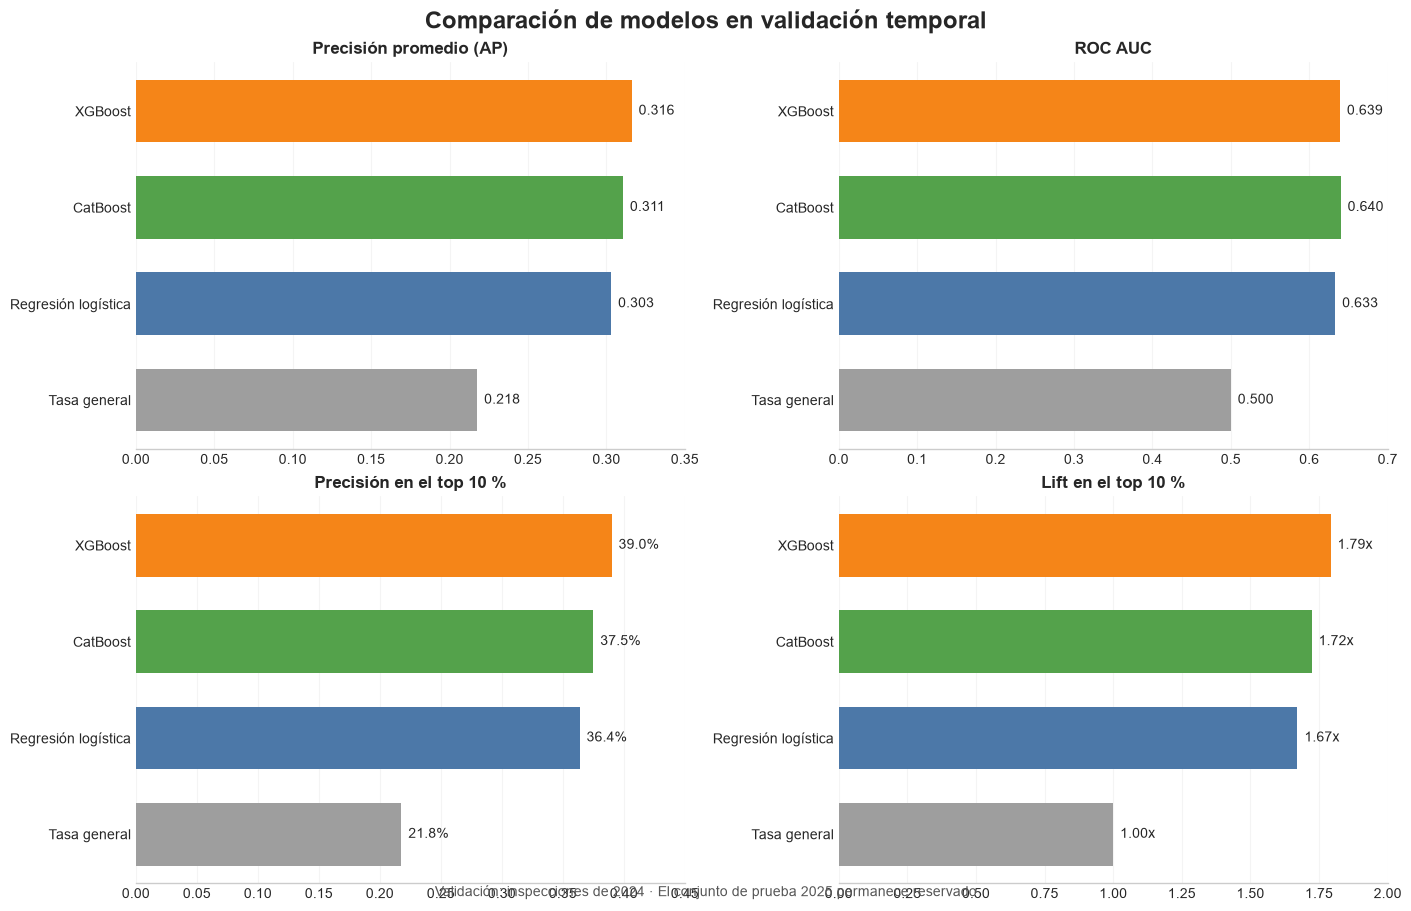

In [19]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

MODEL_ORDER = [
    "XGBoost",
    "CatBoost",
    "Regresión logística",
    "Tasa general",
]

MODEL_COLORS = {
    "XGBoost": "#F58518",
    "CatBoost": "#54A24B",
    "Regresión logística": "#4C78A8",
    "Tasa general": "#9E9E9E",
}

comparison_data = (
    validation_results_df
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

metric_config = [
    (
        "average_precision",
        "Precisión promedio (AP)",
        lambda value: f"{value:.3f}",
        (0, 0.35),
    ),
    (
        "roc_auc",
        "ROC AUC",
        lambda value: f"{value:.3f}",
        (0, 0.70),
    ),
    (
        "precision_at_10_pct",
        "Precisión en el top 10 %",
        lambda value: f"{value:.1%}",
        (0, 0.45),
    ),
    (
        "lift_at_10_pct",
        "Lift en el top 10 %",
        lambda value: f"{value:.2f}x",
        (0, 2.0),
    ),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    constrained_layout=True,
)

for ax, (metric, title, formatter, limits) in zip(
    axes.flat,
    metric_config,
):
    values = comparison_data[metric]

    bars = ax.barh(
        comparison_data["model"],
        values,
        color=comparison_data["model"].map(MODEL_COLORS),
        height=0.65,
    )

    ax.bar_label(
        bars,
        labels=[formatter(value) for value in values],
        padding=5,
        fontsize=10,
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlim(*limits)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.20)
    ax.grid(axis="y", visible=False)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

fig.suptitle(
    "Comparación de modelos en validación temporal",
    fontsize=17,
    fontweight="bold",
)

fig.text(
    0.5,
    0.01,
    "Validación: inspecciones de 2024 · El conjunto de prueba 2025 permanece reservado",
    ha="center",
    fontsize=10,
    color="#555555",
)

fig.savefig(
    FIGURES_DIR / "validation_model_comparison.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


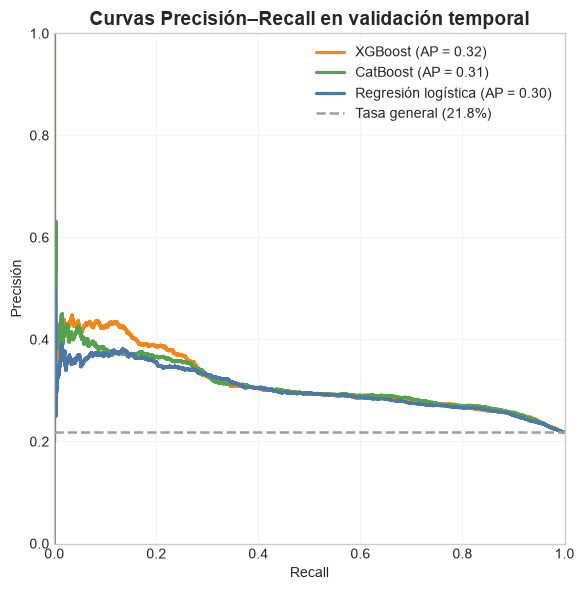

In [20]:
from sklearn.metrics import PrecisionRecallDisplay

validation_probabilities = {
    "XGBoost": xgb_validation_probability,
    "CatBoost": catboost_validation_probability,
    "Regresión logística": logistic_validation_probability,
}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, probabilities in validation_probabilities.items():
    PrecisionRecallDisplay.from_predictions(
        y_validation,
        probabilities,
        name=model_name,
        ax=ax,
        curve_kwargs={
            "color": MODEL_COLORS[model_name],
            "linewidth": 2.3,
        },
    )

validation_base_rate = y_validation.mean()

ax.axhline(
    validation_base_rate,
    color=MODEL_COLORS["Tasa general"],
    linestyle="--",
    linewidth=1.8,
    label=f"Tasa general ({validation_base_rate:.1%})",
)

ax.set_title(
    "Curvas Precisión–Recall en validación temporal",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precisión")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.20)
ax.legend(loc="upper right")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "validation_precision_recall_curve.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


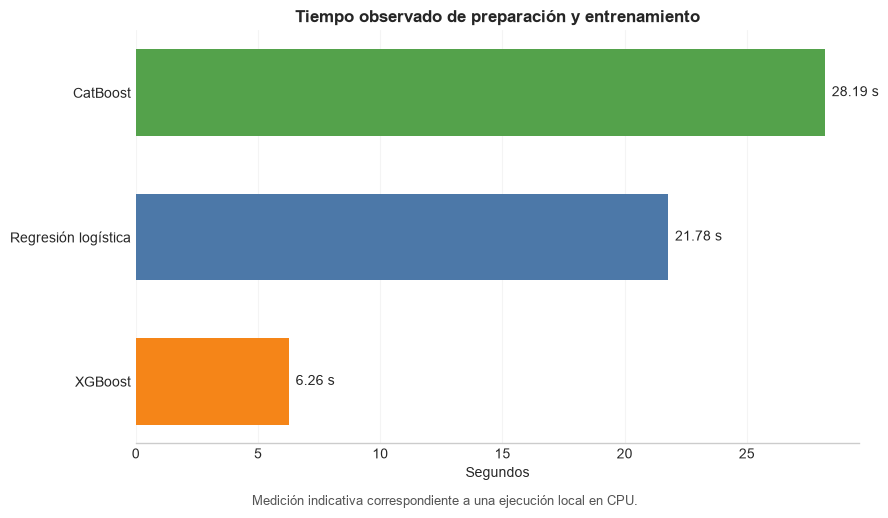

In [21]:
time_data = (
    comparison_data
    .query("model != 'Tasa general'")
    .sort_values("training_seconds")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    time_data["model"],
    time_data["training_seconds"],
    color=time_data["model"].map(MODEL_COLORS),
    height=0.60,
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f} s"
        for value in time_data["training_seconds"]
    ],
    padding=5,
)

ax.set_title(
    "Tiempo observado de preparación y entrenamiento",
    fontweight="bold",
)
ax.set_xlabel("Segundos")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.20)
ax.grid(axis="y", visible=False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.text(
    0.5,
    -0.02,
    "Medición indicativa correspondiente a una ejecución local en CPU.",
    ha="center",
    fontsize=9,
    color="#555555",
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "validation_training_time.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


## 12. Siguiente etapa: evaluación final

Las configuraciones se congelarán con base en 2024. En la siguiente etapa se reentrenarán los modelos con 2019–2024 y se evaluarán una sola vez sobre 2025, utilizando exactamente las mismas métricas.

Esta sección no ejecuta todavía ninguna operación sobre las etiquetas de prueba.
